# Python for Data Analysts
This notebook covers the basic Python concepts and data analysis techniques using `pandas` and `numpy` as discussed in the tutorial video, applied to the provided Olympics dataset.

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style"
)

## 1. Basic Python Concepts
Variables, Data Types, Lists, Dictionaries, and Functions.

In [ ]:
# Variables and Data Types
x = 5                # Integer
y = 5.0              # Float
name = "Data Analyst" # String
is_active = True     # Boolean

print(f"Role: {name}, Value: {x}, Active: {is_active}")

Role: Data Analyst, Value: 5, Active: True


In [ ]:
# Lists and Dictionaries
my_list = [1, 2, 3, 4, 5]
my_dict = {"name": "Python", "type": "Programming Language"}

# Slicing a list
print("First three elements of the list:", my_list[:3])

# Accessing dictionary values
print("Dictionary Name Value:", my_dict["name"])

First three elements of the list: [1, 2, 3]
Dictionary Name Value: Python


In [ ]:
# Functions
def calculate_total(a, b):
    return a + b

print("Total sum:", calculate_total(10, 15))

Total sum: 25


## 2. Data Analysis with Pandas
Loading, exploring, filtering, grouping, and merging datasets.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np

In [ ]:
# Load the datasets you provided
medals = pd.read_excel('Medals.xlsx')
athletes = pd.read_excel('Athletes.xlsx')
coaches = pd.read_excel('Coaches.xlsx')
teams = pd.read_excel('Teams.xlsx')
entries = pd.read_excel('EntriesGender.xlsx')

# View the first 5 rows of the Medals dataset
medals.head()

C:\Users\nn\AppData\Roaming\Python\Python314\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\nn\AppData\Roaming\Python\Python314\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3


In [ ]:
# Basic Data Exploration
print("Columns in Medals dataset:", medals.columns.tolist())

# Get summary statistics for numerical columns
medals.describe()

Columns in Medals dataset: ['Rank', 'Team/NOC', 'Gold', 'Silver', 'Bronze', 'Total', 'Rank by Total']


,Rank,Gold,Silver,Bronze,Total,Rank by Total
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,46.333333,3.655914,3.634409,4.322581,11.612903,43.494624
std,26.219116,7.022471,6.626339,6.210372,19.091332,24.171769
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,24.000000,0.000000,0.000000,1.000000,2.000000,23.000000
50%,46.000000,1.000000,1.000000,2.000000,4.000000,47.000000
75%,70.000000,3.000000,4.000000,5.000000,11.000000,66.000000
max,86.000000,39.000000,41.000000,33.000000,113.000000,77.000000


In [ ]:
# Filtering Data
# Let's filter to see only the performance of the United States
us_medals = medals[medals['Team/NOC'] == 'United States of America']
us_medals

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1


In [ ]:
# Grouping Data (Group By)
# Find the count of athletes in each discipline, sorted highest to lowest
athlete_counts = athletes.groupby('Discipline')['Name'].count().reset_index()
athlete_counts = athlete_counts.rename(columns={'Name': 'Athlete_Count'})
athlete_counts = athlete_counts.sort_values(by='Athlete_Count', ascending=False)

athlete_counts.head(10)

,Discipline,Athlete_Count
4,Athletics,2068
36,Swimming,743
20,Football,567
29,Rowing,496
23,Hockey,406
24,Judo,373
22,Handball,343
32,Shooting,342
31,Sailing,336
30,Rugby Sevens,283


In [ ]:
# Merging (Joining) DataFrames
# Let's merge the Medals data with the Teams data based on the country/NOC name
merged_df = pd.merge(medals, teams, left_on='Team/NOC', right_on='NOC', how='inner')

# Displaying the first few rows of our enriched/merged dataset
merged_df.head()

,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total,Name,Discipline,NOC,Event
0,1,United States of America,39,41,33,113,1,United States,3x3 Basketball,United States of America,Women
1,1,United States of America,39,41,33,113,1,United States,Archery,United States of America,Men's Team
2,1,United States of America,39,41,33,113,1,United States,Archery,United States of America,Mixed Team
3,1,United States of America,39,41,33,113,1,United States,Archery,United States of America,Women's Team
4,1,United States of America,39,41,33,113,1,United States,Artistic Gymnastics,United States of America,Men's Team


## 3. Exploratory Data Analysis (EDA) - Chapter 1 Practical Implementation

Following the concepts from Chapter 1 of "Practical Statistics for Data Scientists", we perform EDA on the Olympics dataset.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

In [ ]:
# Estimates of Location (Mean, Median, Mode)
print("Estimates of Location for Medals:")
print(f"Mean Gold: {medals['Gold'].mean():.2f}")
print(f"Median Gold: {medals['Gold'].median()}")
print(f"Mode Gold: {medals['Gold'].mode().iloc[0]}")

print(f"\nMean Total: {medals['Total'].mean():.2f}")
print(f"Median Total: {medals['Total'].median()}")
print(f"Mode Total: {medals['Total'].mode().iloc[0]}")

Estimates of Location for Medals:
Mean Gold: 3.66
Median Gold: 1.0
Mode Gold: 0

Mean Total: 11.61
Median Total: 4.0
Mode Total: 1


In [ ]:
# Estimates of Variability (Variance, Standard Deviation, IQR)
print("\nEstimates of Variability for Gold Medals:")
print(f"Variance: {medals['Gold'].var():.2f}")
print(f"Standard Deviation: {medals['Gold'].std():.2f}")
print(f"Interquartile Range (IQR): {medals['Gold'].quantile(0.75) - medals['Gold'].quantile(0.25)}")

print(f"\nRange: {medals['Gold'].max() - medals['Gold'].min()}")


Estimates of Variability for Gold Medals:
Variance: 49.32
Standard Deviation: 7.02
Interquartile Range (IQR): 3.0

Range: 39


C:\Users\nn\AppData\Local\Temp\ipykernel_19372\2177415738.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([medals['Gold'], medals['Silver'], medals['Bronze']], labels=['Gold', 'Silver', 'Bronze'])


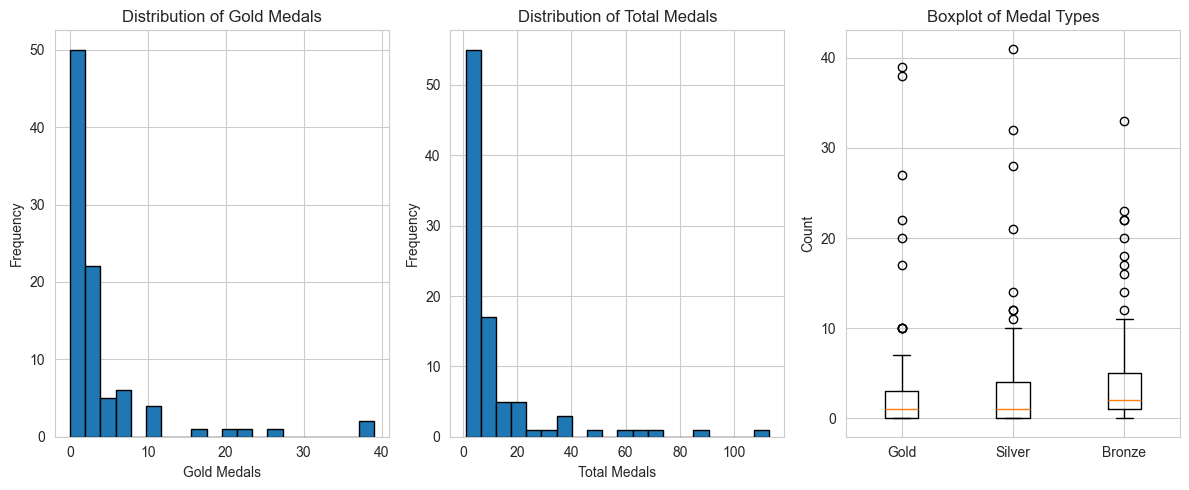

In [ ]:
# Exploring Data Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.hist(medals['Gold'], bins=20, edgecolor='black')
plt.title('Distribution of Gold Medals')
plt.xlabel('Gold Medals')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(medals['Total'], bins=20, edgecolor='black')
plt.title('Distribution of Total Medals')
plt.xlabel('Total Medals')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.boxplot([medals['Gold'], medals['Silver'], medals['Bronze']], labels=['Gold', 'Silver', 'Bronze'])
# plt.boxplot([medals['Gold'], medals['Silver'], medals['Bronze'], medals['Total']], labels=['Gold', 'Silver', 'Bronze','Total'])
plt.title('Boxplot of Medal Types')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Correlation Matrix:
            Gold    Silver    Bronze     Total
Gold    1.000000  0.929046  0.862425  0.970840
Silver  0.929046  1.000000  0.862646  0.969439
Bronze  0.862425  0.862646  1.000000  0.941941
Total   0.970840  0.969439  0.941941  1.000000


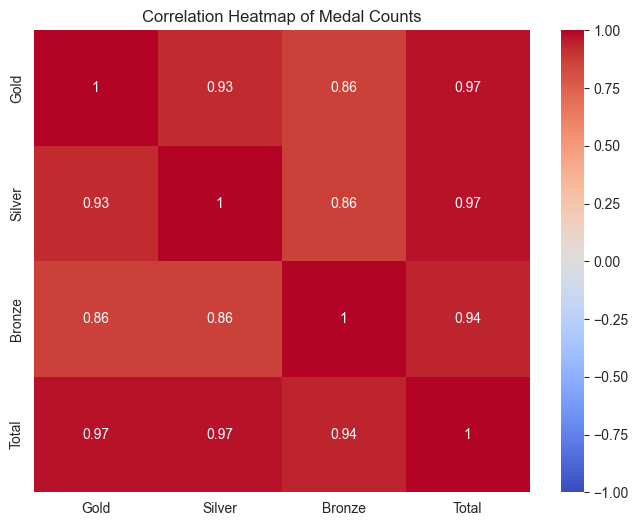

In [ ]:
# Correlation Analysis
correlation_matrix = medals[['Gold', 'Silver', 'Bronze', 'Total']].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Medal Counts')
plt.show()

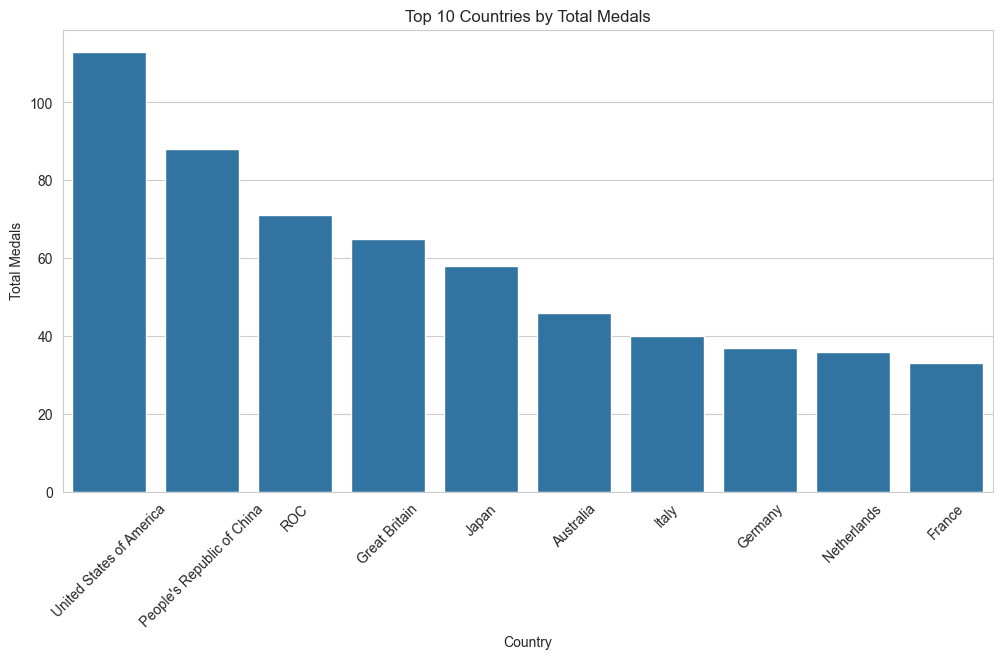


Total Medal Counts:
Gold      340
Silver    338
Bronze    402
dtype: int64


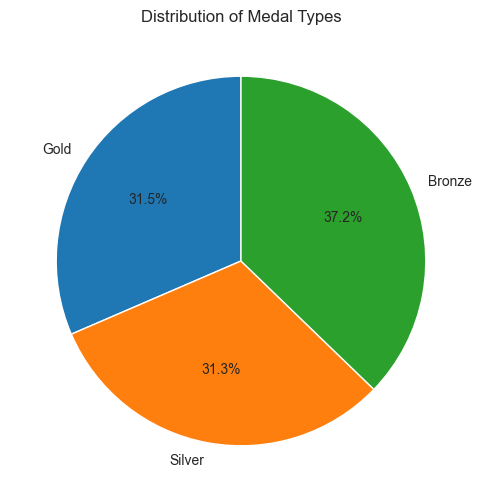

In [ ]:
# Exploring Categorical Data - Top 10 Countries by Total Medals
top_10_countries = medals.nlargest(10, 'Total')

plt.figure(figsize=(12, 6))
sns.barplot(x='Team/NOC', y='Total', data=top_10_countries)
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)
plt.show()

# Frequency of medal types
medal_counts = medals[['Gold', 'Silver', 'Bronze']].sum()
print("\nTotal Medal Counts:")
print(medal_counts)

plt.figure(figsize=(8, 6))
medal_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Medal Types')
plt.ylabel('')
plt.show()